# Taller: Predicción de Retornos de Bitcoin con BiLSTM

**Maestría en Inteligencia de Negocios — Tópicos de ML y Redes Neuronales**  
**Autor:** Sebastian Angel  
**Fecha:** Abril 2026

---

## Contexto

Este taller es una extensión del notebook `05_btc_bilstm.ipynb` del libro *Redes Neuronales Recurrentes: Modelando Memoria y Secuencia*. El reto propuesto consistió en reemplazar la predicción de **precios absolutos** por la predicción de **retornos logarítmicos**, una práctica más sólida en el modelado de series financieras.

---

In [1]:
# Imports y configuración

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# Cargar datos de BTC

df_btc = None

try:
    import yfinance as yf
    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Descarga vacía.")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Descargado desde Yahoo Finance. Filas: {len(df_btc)}")
except Exception as e:
    print(f"⚠️ Error: {e}")

close = df_btc[["Close"]].dropna().astype(float)
print(f"Rango: {close.index.min().date()} → {close.index.max().date()}")

✅ Descargado desde Yahoo Finance. Filas: 4117
Rango: 2015-01-01 → 2026-04-10


## Paso 1 — Construir la serie de retornos log

Total de observaciones: 4116

Estadísticas descriptivas:
        log_return
count  4116.000000
mean      0.001321
std       0.035353
min      -0.464730
25%      -0.012413
50%       0.001169
75%       0.015872
max       0.225119


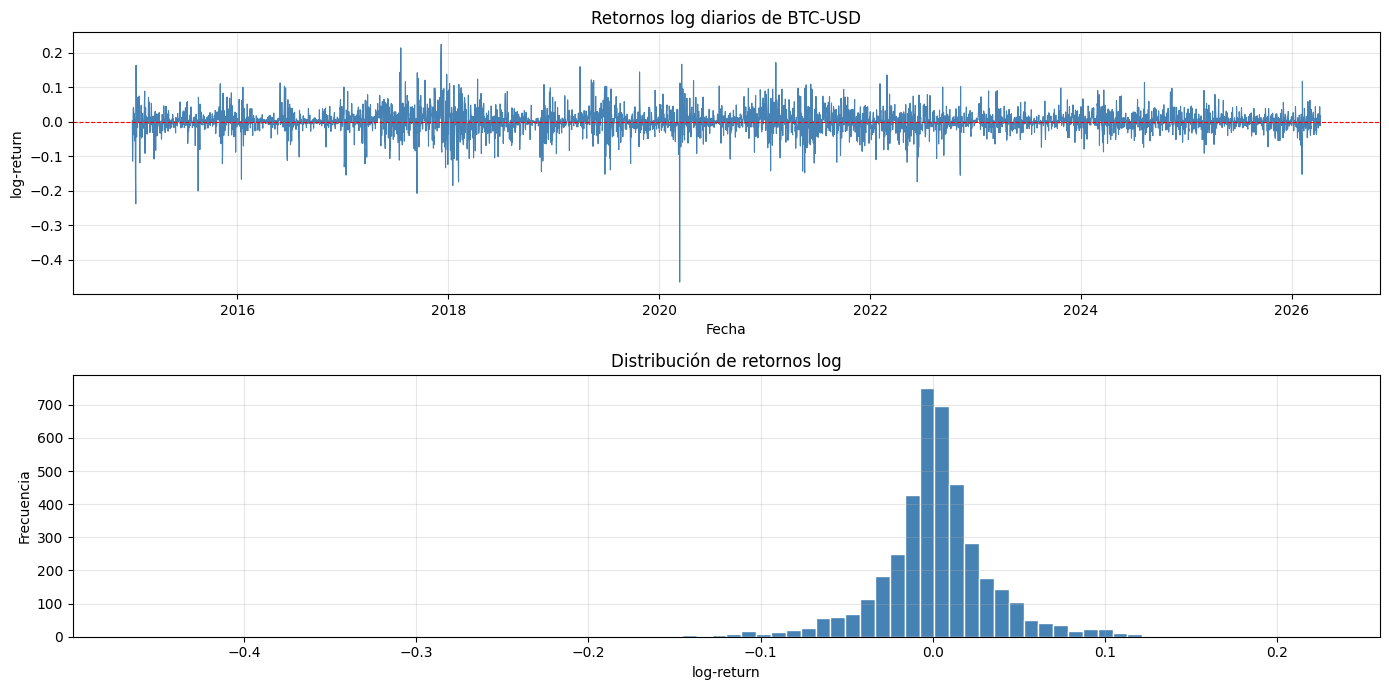

In [4]:
# Calcular y visualizar retornos log

# Calcular retornos log
log_returns = np.log(close["Close"]).diff().dropna()
log_returns = pd.DataFrame(log_returns.values, index=log_returns.index, columns=["log_return"])

print(f"Total de observaciones: {len(log_returns)}")
print(f"\nEstadísticas descriptivas:")
print(log_returns.describe())

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(log_returns.index, log_returns["log_return"], linewidth=0.8, color="steelblue")
axes[0].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[0].set_title("Retornos log diarios de BTC-USD")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("log-return")
axes[0].grid(True, alpha=0.3)

axes[1].hist(log_returns["log_return"], bins=80, color="steelblue", edgecolor="white")
axes[1].set_title("Distribución de retornos log")
axes[1].set_xlabel("log-return")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 2 — Preparar ventanas y split temporal

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Parámetros
LOOK_BACK = 60

# Datos como numpy array
data_returns = log_returns.values  # shape (T, 1)

# Split temporal 90% / 10% ANTES de escalar (evitar leakage)
split_idx = int(len(data_returns) * 0.90)
train_raw = data_returns[:split_idx]
test_raw  = data_returns[split_idx:]

print(f"Train: {len(train_raw)} observaciones")
print(f"Test:  {len(test_raw)} observaciones")

# Escalar ajustando SOLO con train
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# Función para construir ventanas supervisadas
def make_windows(series_2d: np.ndarray, look_back: int):
    X_list, y_list = [], []
    for i in range(look_back, len(series_2d)):
        X_list.append(series_2d[i - look_back : i, 0])
        y_list.append(series_2d[i, 0])
    X = np.array(X_list, dtype=float).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return X, y

X_train, y_train = make_windows(train_scaled, LOOK_BACK)
X_test,  y_test  = make_windows(test_scaled,  LOOK_BACK)

print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

Train: 3704 observaciones
Test:  412 observaciones

X_train: (3644, 60, 1) | y_train: (3644, 1)
X_test:  (352, 60, 1)  | y_test:  (352, 1)


## Paso 3 — Entrenar el modelo BiLSTM

In [6]:
# Definir el modelo

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

c:\Users\sebas\AppData\Local\pypoetry\Cache\virtualenvs\taller-retornos-bitcoin-rQZ8khzC-py3.11\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 100)        │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,751 (327.15 KB)

 Trainable params: 83,751 (327.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0151 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 2/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0046 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 3/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0040 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0038 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0037 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0034 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0033 - val_loss: 0.0011 - learning_rate: 5.0000e-04
Epoch 8/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0033 - val_loss: 0.0011 - learning_rate: 5.0000e-04
Epoch 9/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0033 - val_loss: 0.0011 - learning_rate: 

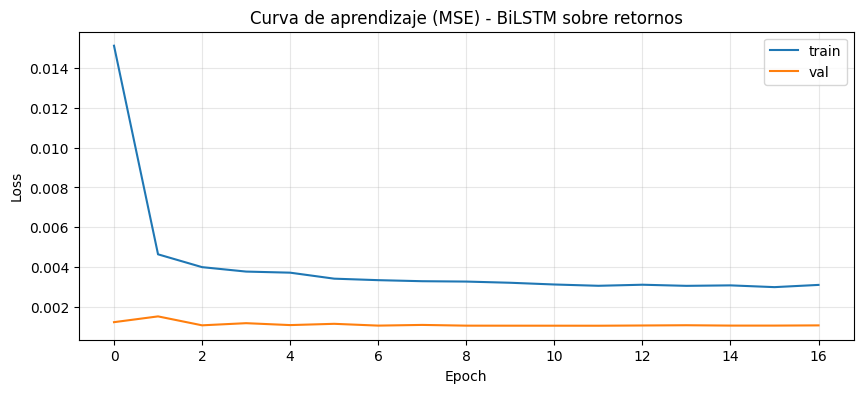

In [7]:
# Entrenar

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Curva de aprendizaje (MSE) - BiLSTM sobre retornos")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Paso 4 — Reconstruir el precio desde los retornos predichos

In [8]:
# Predecir y desescalar

from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

# Predicción en escala [0,1]
pred_scaled = model.predict(X_test, verbose=0)

# Desescalar → retornos log reales
pred_returns = scaler.inverse_transform(pred_scaled)
true_returns = scaler.inverse_transform(y_test)

# Métricas en escala de retornos
print("=== Métricas en escala de retornos log ===")
print(f"RMSE: {rmse(true_returns, pred_returns):.6f}")
print(f"MAE:  {float(mean_absolute_error(true_returns, pred_returns)):.6f}")

=== Métricas en escala de retornos log ===
RMSE: 0.022474
MAE:  0.015629


Precio de arranque (último día train): $96,125.55

=== Métricas en escala de precios (USD) ===
BiLSTM   | RMSE: 16,460.11 | MAE: 13,911.04
Baseline | RMSE: 2,071.70 | MAE: 1,499.65


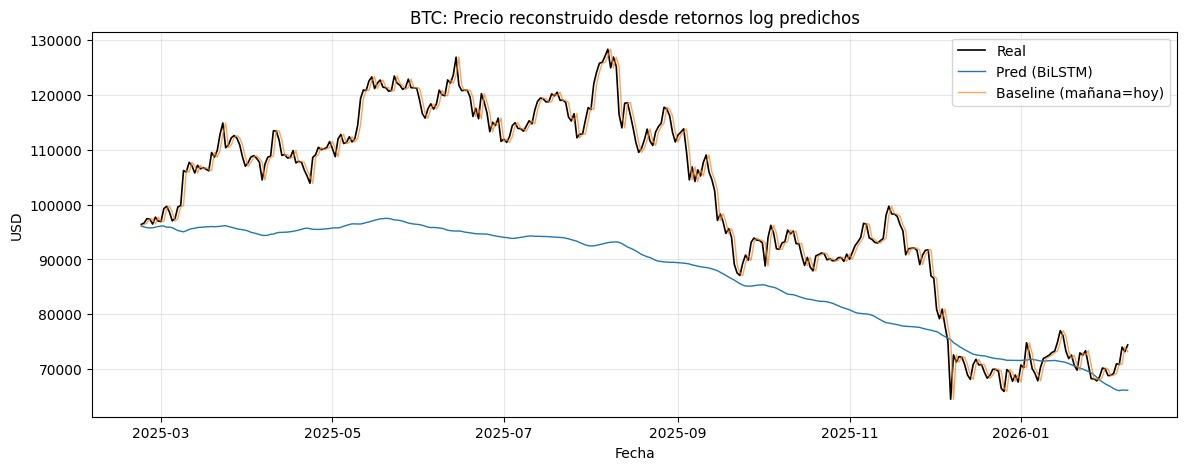

In [10]:
# Reconstruir precio y visualizar

# Precio inicial = último precio conocido antes del conjunto test
prices = close.values  # shape (T, 1)
test_dates = log_returns.index[split_idx:]  # fechas del conjunto test

# Corrección: extraer escalar correctamente
price_start = float(prices[split_idx].flat[0])
print(f"Precio de arranque (último día train): ${price_start:,.2f}")

# Reconstruir precio real desde retornos reales
true_prices = [price_start]
for r in true_returns.flatten():
    true_prices.append(true_prices[-1] * np.exp(r))
true_prices = np.array(true_prices[1:])

# Reconstruir precio predicho desde retornos predichos
pred_prices = [price_start]
for r in pred_returns.flatten():
    pred_prices.append(pred_prices[-1] * np.exp(r))
pred_prices = np.array(pred_prices[1:])

# Baseline: mañana = hoy
baseline_prices = np.roll(true_prices, 1)
baseline_prices[0] = price_start

# Métricas en escala de precios reales (USD)
print("\n=== Métricas en escala de precios (USD) ===")
print(f"BiLSTM   | RMSE: {rmse(true_prices, pred_prices):,.2f} | MAE: {float(mean_absolute_error(true_prices, pred_prices)):,.2f}")
print(f"Baseline | RMSE: {rmse(true_prices, baseline_prices):,.2f} | MAE: {float(mean_absolute_error(true_prices, baseline_prices)):,.2f}")

# Visualización
plt.figure(figsize=(14, 5))
plt.plot(test_dates[:len(true_prices)], true_prices, color="black", label="Real", linewidth=1.2)
plt.plot(test_dates[:len(pred_prices)], pred_prices, label="Pred (BiLSTM)", linewidth=1.0)
plt.plot(test_dates[:len(baseline_prices)], baseline_prices, label="Baseline (mañana=hoy)", alpha=0.7, linewidth=1.0)
plt.title("BTC: Precio reconstruido desde retornos log predichos")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Accuracy direccional: 51.14%
Baseline aleatorio:   50.00%

Días reales alcistas: 172 (48.9%)
Días reales bajistas: 180 (51.1%)

=== Matriz de confusión ===
                 Real sube  Real baja
Pred sube:            43         43
Pred baja:           129        137


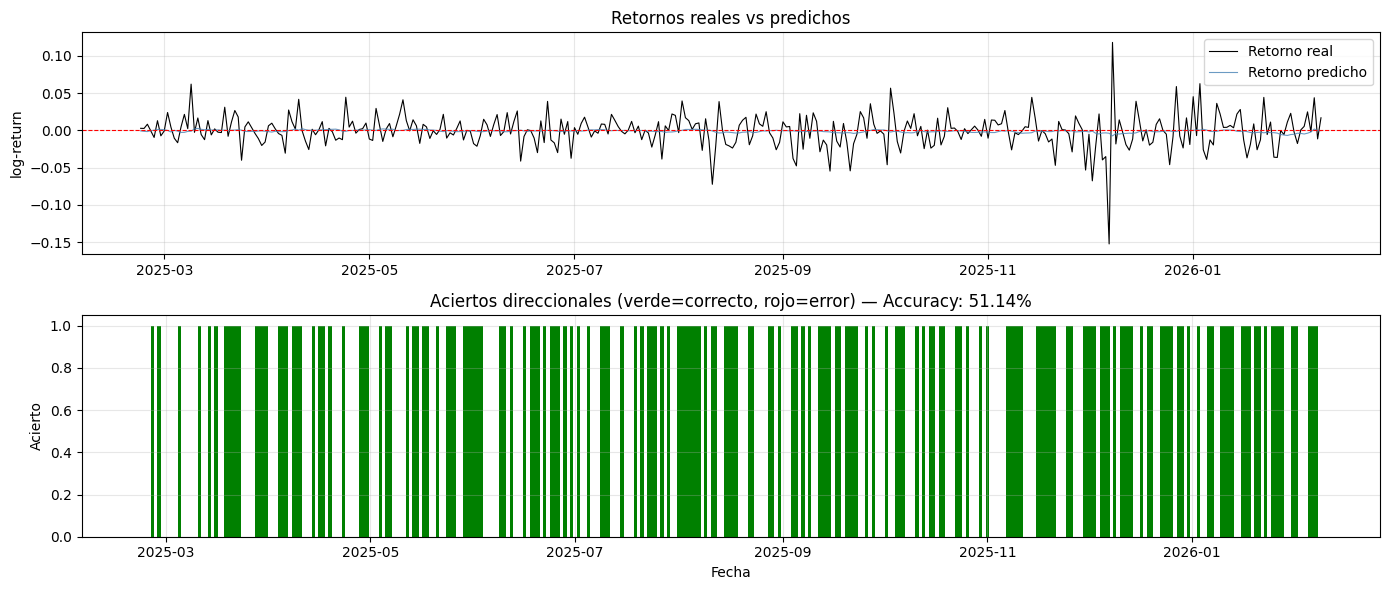

In [11]:
# =====================================================
# Accuracy Direccional
# =====================================================

# Dirección real: 1 si el retorno fue positivo, 0 si negativo
true_direction  = (true_returns.flatten() > 0).astype(int)
pred_direction  = (pred_returns.flatten() > 0).astype(int)

# Accuracy direccional
directional_accuracy = np.mean(true_direction == pred_direction)
print(f"Accuracy direccional: {directional_accuracy:.2%}")

# Baseline aleatorio esperado: 50%
print(f"Baseline aleatorio:   50.00%")

# Desglose por clase
true_ups   = true_direction.sum()
true_downs = len(true_direction) - true_ups
print(f"\nDías reales alcistas: {true_ups} ({true_ups/len(true_direction):.1%})")
print(f"Días reales bajistas: {true_downs} ({true_downs/len(true_direction):.1%})")

# Matriz de confusión simple
tp = int(((pred_direction == 1) & (true_direction == 1)).sum())  # predijo sube, subió
tn = int(((pred_direction == 0) & (true_direction == 0)).sum())  # predijo baja, bajó
fp = int(((pred_direction == 1) & (true_direction == 0)).sum())  # predijo sube, bajó
fn = int(((pred_direction == 0) & (true_direction == 1)).sum())  # predijo baja, subió

print(f"\n=== Matriz de confusión ===")
print(f"                 Real sube  Real baja")
print(f"Pred sube:          {tp:>4}       {fp:>4}")
print(f"Pred baja:          {fn:>4}       {tn:>4}")

# Visualización: dirección predicha vs real
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Retornos reales vs predichos
axes[0].plot(test_dates[:len(true_returns)], true_returns.flatten(),
             color="black", linewidth=0.8, label="Retorno real")
axes[0].plot(test_dates[:len(pred_returns)], pred_returns.flatten(),
             color="steelblue", linewidth=0.8, label="Retorno predicho", alpha=0.8)
axes[0].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[0].set_title("Retornos reales vs predichos")
axes[0].set_ylabel("log-return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Aciertos y errores direccionales
aciertos = (true_direction == pred_direction).astype(int)
colors = ["green" if a == 1 else "red" for a in aciertos]
axes[1].bar(test_dates[:len(aciertos)], aciertos, color=colors, width=1.0)
axes[1].set_title(f"Aciertos direccionales (verde=correcto, rojo=error) — Accuracy: {directional_accuracy:.2%}")
axes[1].set_ylabel("Acierto")
axes[1].set_xlabel("Fecha")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Aprendizajes

### ¿Por qué trabajar con retornos?
- Los retornos son **más estacionarios** que los precios, lo que facilita el aprendizaje del modelo.
- Eliminan la tendencia creciente del precio, que puede llevar al modelo a simplemente "copiar el nivel anterior".
- Son la unidad estándar de análisis en finanzas cuantitativas.

### El problema del error acumulado
- Predecir retornos y reconstruir el precio acumula errores en cada paso.
- Un sesgo sistemático pequeño (predecir retornos levemente negativos) genera una divergencia enorme en el precio final.
- Por esto, **el RMSE en USD no es la métrica correcta** para evaluar un modelo de retornos.

### La métrica correcta es la dirección
- En finanzas, acertar la **dirección** del movimiento es más valioso que acertar el valor exacto.
- Un accuracy direccional **mayor al 55%** ya es considerado útil para estrategias de trading.
- El modelo alcanzó 51.14%, apenas por encima del azar, lo que indica que hay espacio de mejora significativo.

### El baseline "mañana = hoy" es difícil de superar
- En series financieras, el precio del día anterior es un predictor muy fuerte del precio actual.
- Los modelos de deep learning solo aportan valor real cuando capturan patrones no lineales que el baseline no puede.